# Plant community analysis across climate zones

End-to-end pipeline: raw plot workbooks (wide format) → tidy data → alpha diversity →
community composition (PERMANOVA / PERMDISP / PCoA) → sampling completeness → figures → summary tables.

**To use with real data:** replace `INPUT_FILE` in the next cell with your actual workbook (one sheet
per plot, same layout as the template), update `ZONE_MAP` to match your real plot → climate-zone
assignment, and re-run the whole notebook (Kernel → Restart & Run All). Every table, figure, and
statistic below will regenerate from your real numbers.

Currently configured to run on **mock/simulated data** — treat every result below as a pipeline
test, not a biological finding.

## 0. Setup

In [1]:
import openpyxl
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import permanova, permdisp, DistanceMatrix
from skbio.stats.ordination import pcoa

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', None)

INPUT_FILE = 'mock_plant_survey_5_plots.xlsx'   # <-- point this at your real workbook

# Map each sheet name (= plot) to its climate zone. Edit to match your real plots/sites.
ZONE_MAP = {
    'Plot_1': 'Wet_evergreen',
    'Plot_2': 'Wet_evergreen',
    'Plot_3': 'Moist_deciduous',
    'Plot_4': 'Dry_deciduous',
    'Plot_5': 'Dry_deciduous',
}

ZONE_ORDER = ['Wet_evergreen', 'Moist_deciduous', 'Dry_deciduous']
SEASON_ORDER = ['Pre_monsoon', 'Monsoon', 'Post_monsoon']
PALETTE = {'Wet_evergreen': '#1D9E75', 'Moist_deciduous': '#BA7517', 'Dry_deciduous': '#993C1D'}

## 1. Load raw plot sheets and tidy to long format

Each sheet is one plot, laid out exactly like the original field template: a `PLANT` column,
and three count columns (`pre monsoon`, `monsoon`, `post monsoon`) with a `TOTAL` row at the
bottom. We convert this into one row per Plot × Season × Species — the format every downstream
package (and this notebook) expects.

In [2]:
wb = openpyxl.load_workbook(INPUT_FILE, data_only=True)

records = []
for sheet_name in wb.sheetnames:
    ws = wb[sheet_name]
    zone = ZONE_MAP.get(sheet_name)
    if zone is None:
        print(f'Skipping sheet "{sheet_name}" — not found in ZONE_MAP')
        continue
    rows = list(ws.iter_rows(values_only=True))
    for row in rows[2:]:  # skip the two header rows
        species = row[0]
        if species is None or str(species).strip().upper() == 'TOTAL':
            continue
        pre, mon, post = row[1], row[2], row[3]
        for season, val in zip(['Pre_monsoon', 'Monsoon', 'Post_monsoon'], [pre, mon, post]):
            records.append({
                'Plot_ID': sheet_name,
                'Climate_Zone': zone,
                'Season': season,
                'Species': str(species).strip(),
                'Count': val if val is not None else 0,
            })

df = pd.DataFrame(records)
print(f'{len(df)} rows | {df["Plot_ID"].nunique()} plots | {df["Species"].nunique()} species')
df.head(10)

705 rows | 5 plots | 47 species


,Plot_ID,Climate_Zone,Season,Species,Count
0,Plot_1,Wet_evergreen,Pre_monsoon,Adiantum latifolium,0
1,Plot_1,Wet_evergreen,Monsoon,Adiantum latifolium,0
2,Plot_1,Wet_evergreen,Post_monsoon,Adiantum latifolium,0
3,Plot_1,Wet_evergreen,Pre_monsoon,Adiantum philippense,0
4,Plot_1,Wet_evergreen,Monsoon,Adiantum philippense,1
5,Plot_1,Wet_evergreen,Post_monsoon,Adiantum philippense,0
6,Plot_1,Wet_evergreen,Pre_monsoon,Agrostis capillaris,0
7,Plot_1,Wet_evergreen,Monsoon,Agrostis capillaris,0
8,Plot_1,Wet_evergreen,Post_monsoon,Agrostis capillaris,0
9,Plot_1,Wet_evergreen,Pre_monsoon,Ailanthes sp.,0


In [3]:
# Sanity checks worth running on real data before trusting anything downstream
print('Plots per climate zone:')
print(df.drop_duplicates('Plot_ID').groupby('Climate_Zone')['Plot_ID'].count())
print()
print('Any negative counts?', (df['Count'] < 0).any())
print('Any missing species names?', df['Species'].isna().any())
print()
print('Species name variants to double-check for typos / inconsistent capitalization:')
for s in sorted(df['Species'].unique()):
    print(' -', s)

Plots per climate zone:
Climate_Zone
Dry_deciduous      2
Moist_deciduous    1
Wet_evergreen      2
Name: Plot_ID, dtype: int64

Any negative counts? False
Any missing species names? False

Species name variants to double-check for typos / inconsistent capitalization:
 - Adiantum latifolium
 - Adiantum philippense
 - Agrostis capillaris
 - Ailanthes sp.
 - Artocarpus  hirsutus
 - Artocarpus heterophyllus
 - Bauhinia sp.
 - Coccinia grandis
 - Cocus nucifera
 - Colocasia esculenta
 - Commelina diffusa
 - Cyathillium
 - Cyperus compressus
 - Dieffenbachia seguine
 - Emilia
 - Euphorbia heterophylla
 - Evolvulus nummularis
 - Grona triflora
 - Hibiscus rosa-sinensis cream and red
 - Hygrophila auriculata
 - Ischane globosa
 - Jasmine
 - Justicia diffusa
 - MImosa pudica
 - Mangifera indica
 - Musa paradisica
 - Nelumbo nucifera
 - Ocimum teneuflorum
 - Phyllanthus amarus
 - Phyllanthus myrtifolius
 - Polyscias guilfoylei
 - Rostellularia
 - Ruelia tuberosa
 - Scandoxus multi sp
 - Spermoc

## 2. Alpha diversity per plot × season

Species richness (S), Shannon–Wiener diversity (H'), Simpson's diversity (1 − D), and Pielou's
evenness (J') — the standard four. Computed per plot-season sample so they can be modeled later
against climate zone and season (e.g. with a mixed-effects model in R: `lmer(Shannon_H ~
Climate_Zone * Season + (1|Plot_ID))`).

In [4]:
def shannon(counts):
    counts = np.asarray(counts)
    counts = counts[counts > 0]
    if counts.sum() == 0:
        return 0.0
    p = counts / counts.sum()
    return -np.sum(p * np.log(p))

def simpson_1mD(counts):
    counts = np.asarray(counts)
    n = counts.sum()
    if n <= 1:
        return 0.0
    return 1 - np.sum(counts * (counts - 1)) / (n * (n - 1))

def richness(counts):
    return int(np.sum(np.asarray(counts) > 0))

def pielou(H, S):
    return H / np.log(S) if S > 1 else np.nan

rows = []
for (plot, zone, season), g in df.groupby(['Plot_ID', 'Climate_Zone', 'Season']):
    counts = g['Count'].values
    S, H, Dinv = richness(counts), shannon(counts), simpson_1mD(counts)
    rows.append(dict(Plot_ID=plot, Climate_Zone=zone, Season=season,
                      Total_Individuals=int(counts.sum()), Richness=S,
                      Shannon_H=round(H, 3), Simpson_1mD=round(Dinv, 3),
                      Pielou_J=round(pielou(H, S), 3)))

diversity = pd.DataFrame(rows).sort_values(['Climate_Zone', 'Plot_ID', 'Season']).reset_index(drop=True)
diversity

,Plot_ID,Climate_Zone,Season,Total_Individuals,Richness,Shannon_H,Simpson_1mD,Pielou_J
0,Plot_4,Dry_deciduous,Monsoon,405,38,3.192,0.948,0.878
1,Plot_4,Dry_deciduous,Post_monsoon,274,38,3.258,0.955,0.896
2,Plot_4,Dry_deciduous,Pre_monsoon,213,33,3.169,0.951,0.906
3,Plot_5,Dry_deciduous,Monsoon,422,39,3.387,0.963,0.924
4,Plot_5,Dry_deciduous,Post_monsoon,244,37,3.296,0.957,0.913
5,Plot_5,Dry_deciduous,Pre_monsoon,222,33,3.237,0.959,0.926
6,Plot_3,Moist_deciduous,Monsoon,396,33,3.122,0.949,0.893
7,Plot_3,Moist_deciduous,Post_monsoon,344,31,3.069,0.946,0.894
8,Plot_3,Moist_deciduous,Pre_monsoon,262,27,2.868,0.930,0.870
9,Plot_1,Wet_evergreen,Monsoon,370,32,3.150,0.952,0.909


In [5]:
zone_summary = diversity.groupby('Climate_Zone').agg(
    n_plot_seasons=('Plot_ID', 'count'),
    mean_richness=('Richness', 'mean'), sd_richness=('Richness', 'std'),
    mean_shannon=('Shannon_H', 'mean'), sd_shannon=('Shannon_H', 'std'),
    mean_pielou=('Pielou_J', 'mean'),
).round(2).reindex(ZONE_ORDER)
zone_summary   # Table 1 in the manuscript

,n_plot_seasons,mean_richness,sd_richness,mean_shannon,sd_shannon,mean_pielou
Climate_Zone,,,,,,
Wet_evergreen,6,32.67,3.44,3.09,0.08,0.89
Moist_deciduous,3,30.33,3.06,3.02,0.13,0.89
Dry_deciduous,6,36.33,2.66,3.26,0.08,0.91


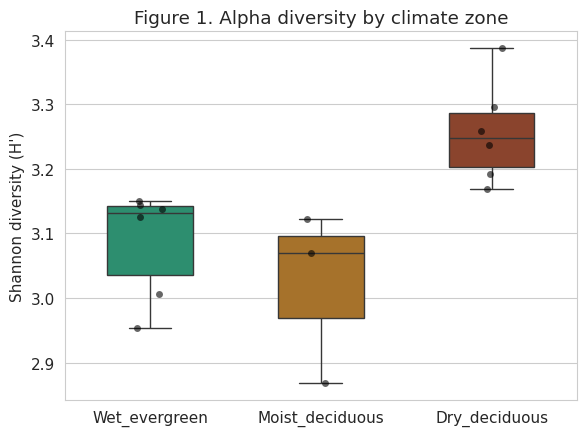

In [6]:
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.boxplot(data=diversity, x='Climate_Zone', y='Shannon_H', order=ZONE_ORDER,
            hue='Climate_Zone', palette=PALETTE, legend=False, ax=ax, width=0.5, fliersize=0)
sns.stripplot(data=diversity, x='Climate_Zone', y='Shannon_H', order=ZONE_ORDER,
              color='black', size=5, alpha=0.6, jitter=True, ax=ax)
ax.set_xlabel(''); ax.set_ylabel("Shannon diversity (H')")
ax.set_title('Figure 1. Alpha diversity by climate zone')
plt.tight_layout()
plt.savefig('fig1_shannon_by_zone.png', dpi=200)
plt.show()

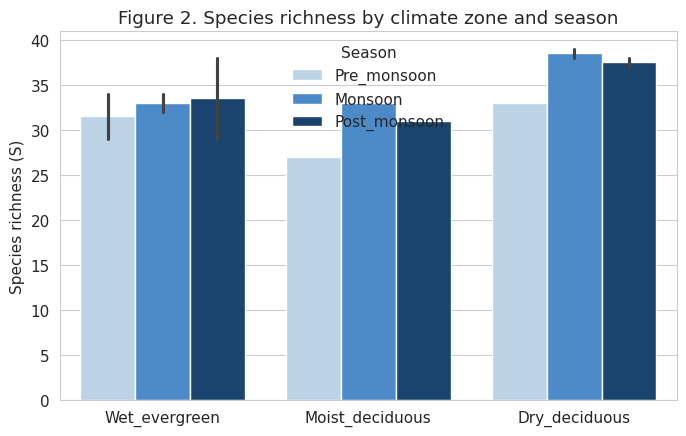

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=diversity, x='Climate_Zone', y='Richness', hue='Season',
            order=ZONE_ORDER, hue_order=SEASON_ORDER, ax=ax,
            palette=['#B4D4EC', '#378ADD', '#0C447C'])
ax.set_xlabel(''); ax.set_ylabel('Species richness (S)')
ax.set_title('Figure 2. Species richness by climate zone and season')
ax.legend(title='Season', frameon=False)
plt.tight_layout()
plt.savefig('fig2_richness_by_zone_season.png', dpi=200)
plt.show()

## 3. Community composition: PERMANOVA, PERMDISP, PCoA

Aggregate to a plot-season × species abundance matrix, compute Bray–Curtis dissimilarity, then:

- **PERMANOVA** — does composition differ by climate zone / season?
- **PERMDISP** — is that difference (partly) just unequal within-group spread? Always check this
  alongside PERMANOVA; a significant PERMANOVA with a significant PERMDISP means the two effects
  are entangled and both need to be reported.
- **PCoA** — 2D ordination for visualization.

In [8]:
mat = df.pivot_table(index=['Plot_ID', 'Climate_Zone', 'Season'], columns='Species',
                      values='Count', aggfunc='sum', fill_value=0).reset_index()
meta = mat[['Plot_ID', 'Climate_Zone', 'Season']].copy()
meta['Sample_ID'] = meta['Plot_ID'] + '_' + meta['Season']
species_cols = [c for c in mat.columns if c not in ['Plot_ID', 'Climate_Zone', 'Season']]
abund = mat[species_cols].values

bc = squareform(pdist(abund, metric='braycurtis'))
dm = DistanceMatrix(bc, ids=meta['Sample_ID'].tolist())

res_zone = permanova(dm, meta['Climate_Zone'].values, permutations=999)
res_season = permanova(dm, meta['Season'].values, permutations=999)
res_disp = permdisp(dm, meta['Climate_Zone'].values, permutations=999)

print('=== PERMANOVA: Climate_Zone ===\n', res_zone, '\n')
print('=== PERMANOVA: Season ===\n', res_season, '\n')
print('=== PERMDISP: Climate_Zone (dispersion homogeneity check) ===\n', res_disp)

=== PERMANOVA: Climate_Zone ===
 method name               PERMANOVA
test statistic name        pseudo-F
sample size                      15
number of groups                  3
test statistic             4.104373
p-value                       0.001
number of permutations          999
Name: PERMANOVA results, dtype: object 

=== PERMANOVA: Season ===
 method name               PERMANOVA
test statistic name        pseudo-F
sample size                      15
number of groups                  3
test statistic             0.406552
p-value                       0.982
number of permutations          999
Name: PERMANOVA results, dtype: object 

=== PERMDISP: Climate_Zone (dispersion homogeneity check) ===
 method name                PERMDISP
test statistic name         F-value
sample size                      15
number of groups                  3
test statistic            49.237557
p-value                       0.001
number of permutations          999
Name: PERMDISP results, dtype: object


Proportion of variance explained — PC1, PC2: [0.263, 0.218]


/usr/local/lib/python3.12/dist-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:222: RuntimeWarning: EIGH: since no value for dimensions is specified, PCoA for all dimensions will be computed, which may result in long computation time if the original distance matrix is large.
  warn(
/usr/local/lib/python3.12/dist-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:359: RuntimeWarning: The result contains negative eigenvalues that are large in magnitude, which may suggest result inaccuracy. See Notes for details. The negative-most eigenvalue is -0.007115394652741401 whereas the largest positive one is 0.7054372985732358.
  warn(


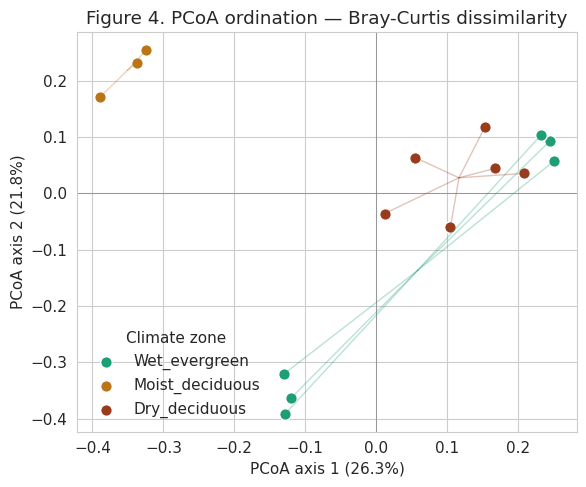

In [9]:
ordination = pcoa(dm)
coords = ordination.samples[['PC1', 'PC2']].copy()
coords['Climate_Zone'] = meta['Climate_Zone'].values
coords['Season'] = meta['Season'].values
coords['Plot_ID'] = meta['Plot_ID'].values
prop_explained = ordination.proportion_explained.iloc[:2].round(3)
print('Proportion of variance explained — PC1, PC2:', prop_explained.tolist())

fig, ax = plt.subplots(figsize=(6, 5))
for zone in ZONE_ORDER:
    sub = coords[coords['Climate_Zone'] == zone]
    ax.scatter(sub['PC1'], sub['PC2'], label=zone, color=PALETTE[zone], s=70, edgecolor='white')
    if len(sub) >= 3:
        cx, cy = sub[['PC1', 'PC2']].values.mean(axis=0)
        for x, y in sub[['PC1', 'PC2']].values:
            ax.plot([cx, x], [cy, y], color=PALETTE[zone], alpha=0.3, linewidth=1)
ax.axhline(0, color='gray', linewidth=0.5); ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel(f'PCoA axis 1 ({prop_explained.iloc[0]*100:.1f}%)')
ax.set_ylabel(f'PCoA axis 2 ({prop_explained.iloc[1]*100:.1f}%)')
ax.set_title('Figure 4. PCoA ordination — Bray-Curtis dissimilarity')
ax.legend(frameon=False, title='Climate zone')
plt.tight_layout()
plt.savefig('fig3_pcoa_ordination.png', dpi=200)
plt.show()

## 4. Sampling completeness: species accumulation curves

Randomly reorders plot-season samples within each climate zone many times and tracks cumulative
species richness. Curves that plateau indicate sampling was sufficient to capture most species
present; curves still climbing steeply suggest more plots/seasons would likely add species — an
important caveat for any richness comparison across zones with unequal sampling effort.

For a submission, consider replacing this quick accumulation curve with proper Hill-number
rarefaction/extrapolation (`iNEXT` in R) to get confidence intervals on the estimates.

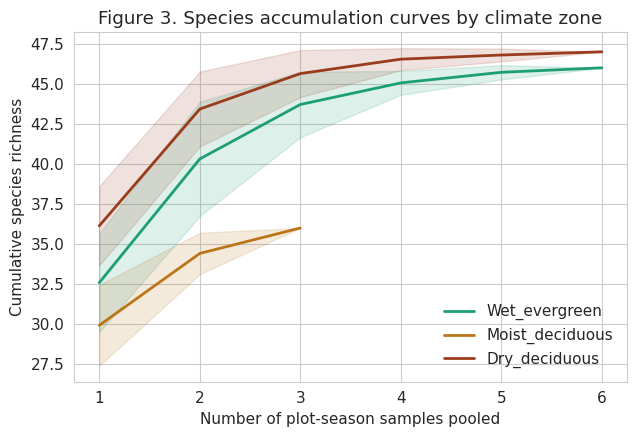

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
rng = np.random.default_rng(1)
n_reps = 200

for zone in ZONE_ORDER:
    sub = df[df['Climate_Zone'] == zone]
    sample_species = [set(g.loc[g['Count'] > 0, 'Species'])
                       for _, g in sub.groupby(['Plot_ID', 'Season'])]
    n_samples = len(sample_species)
    acc = np.zeros((n_reps, n_samples))
    for rep in range(n_reps):
        order = rng.permutation(n_samples)
        seen = set()
        for i, idx in enumerate(order):
            seen |= sample_species[idx]
            acc[rep, i] = len(seen)
    mean_acc, sd_acc = acc.mean(axis=0), acc.std(axis=0)
    x = np.arange(1, n_samples + 1)
    ax.plot(x, mean_acc, color=PALETTE[zone], label=zone, linewidth=2)
    ax.fill_between(x, mean_acc - sd_acc, mean_acc + sd_acc, color=PALETTE[zone], alpha=0.15)

ax.set_xlabel('Number of plot-season samples pooled')
ax.set_ylabel('Cumulative species richness')
ax.set_title('Figure 3. Species accumulation curves by climate zone')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('fig4_species_accumulation.png', dpi=200)
plt.show()

## 5. Save outputs

Writes the tidy dataset, diversity table, zone summary, and PERMANOVA/PERMDISP results to disk
so they can be pulled straight into the manuscript (tables) or cited in the text (statistics).

In [11]:
df.to_csv('tidy_data.csv', index=False)
diversity.to_csv('diversity_indices.csv', index=False)
zone_summary.to_csv('zone_summary.csv')
coords.to_csv('pcoa_coords.csv', index=False)

with open('permanova_results.txt', 'w') as f:
    f.write('PERMANOVA - Climate_Zone\n' + str(res_zone) + '\n\n')
    f.write('PERMANOVA - Season\n' + str(res_season) + '\n\n')
    f.write('PERMDISP - Climate_Zone\n' + str(res_disp) + '\n\n')
    f.write(f'PCoA proportion explained PC1, PC2: {prop_explained.tolist()}\n')

print('Saved: tidy_data.csv, diversity_indices.csv, zone_summary.csv, pcoa_coords.csv, permanova_results.txt')
print('Saved: fig1_shannon_by_zone.png, fig2_richness_by_zone_season.png, fig3_pcoa_ordination.png, fig4_species_accumulation.png')

Saved: tidy_data.csv, diversity_indices.csv, zone_summary.csv, pcoa_coords.csv, permanova_results.txt
Saved: fig1_shannon_by_zone.png, fig2_richness_by_zone_season.png, fig3_pcoa_ordination.png, fig4_species_accumulation.png


## 6. Not yet covered here — next steps for submission

- **Indicator species analysis** (`indicspecies::multipatt` in R) — which species characterize each
  climate zone. Usually a paper's most concrete, citable result; not available in a maintained
  Python package, so this step is easiest done in R.
- **Constrained ordination** (`vegan::rda`/`cca` in R) against measured plot covariates (canopy
  cover, soil moisture, elevation, disturbance) — tests *why* composition differs, not just *that*
  it differs.
- **Mixed-effects models** on the diversity indices above (`lme4`/`glmmTMB` in R, or
  `statsmodels`/`pymer4` in Python) with plot nested in site as a random effect, once you have
  ≥2–3 independent sites per climate zone.
- **Rarefaction/extrapolation with Hill numbers** (`iNEXT` in R) to replace the quick accumulation
  curves in Section 4 with proper confidence intervals.
- Archive the final `tidy_data.csv` and this notebook together (Zenodo/Dryad, with a DOI) —
  expected by nearly all high-impact ecology journals as a condition of publication.